In [1]:
# Add to the end of CELL1 imports:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt
from patchify import patchify

# Enable unsafe deserialization for Lambda layers
tf.keras.config.enable_unsafe_deserialization()

2026-01-12 00:36:53.454325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-12 00:36:53.584453: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [3]:
# Load the model you trained in task5_training.ipynb
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, concatenate, Lambda
import tensorflow as tf

patch_size = 256
example_file_name = f'alex_240247_unet_model_{patch_size}px.h5'

# Approach: Rebuild model architecture and load weights only
# This avoids Lambda layer serialization issues with H5 format
def unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    """Rebuild the exact same architecture from training."""
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    
    # Convert grayscale to 3 channels for MobileNetV2
    if IMG_CHANNELS == 1:
        x = Lambda(lambda x: tf.repeat(x, 3, axis=-1))(inputs)
    else:
        x = inputs
    
    encoder = MobileNetV2(input_tensor=x, weights='imagenet', include_top=False, alpha=1.0)
    
    skip1 = encoder.get_layer('block_1_expand_relu').output
    skip2 = encoder.get_layer('block_3_expand_relu').output
    skip3 = encoder.get_layer('block_6_expand_relu').output
    skip4 = encoder.get_layer('block_13_expand_relu').output
    bottleneck = encoder.get_layer('out_relu').output
    
    # Decoder
    up1 = UpSampling2D(size=(2, 2))(bottleneck)
    up1 = concatenate([up1, skip4])
    conv1 = Conv2D(512, (3, 3), activation='relu', padding='same')(up1)
    conv1 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv1)
    
    up2 = UpSampling2D(size=(2, 2))(conv1)
    up2 = concatenate([up2, skip3])
    conv2 = Conv2D(256, (3, 3), activation='relu', padding='same')(up2)
    conv2 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv2)
    
    up3 = UpSampling2D(size=(2, 2))(conv2)
    up3 = concatenate([up3, skip2])
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(up3)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    
    up4 = UpSampling2D(size=(2, 2))(conv3)
    up4 = concatenate([up4, skip1])
    conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(up4)
    conv4 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv4)
    
    up5 = UpSampling2D(size=(2, 2))(conv4)
    conv5 = Conv2D(32, (3, 3), activation='relu', padding='same')(up5)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Build model with same architecture
model = unet_model(patch_size, patch_size, 1)

# Load weights from trained model
model.load_weights(example_file_name)

print("Model loaded successfully with weights from training")

/tmp/ipykernel_258557/559434534.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  encoder = MobileNetV2(input_tensor=x, weights='imagenet', include_top=False, alpha=1.0)
2026-01-12 00:37:22.613261: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768178242.880591  258557 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 41656 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9


Model loaded successfully with weights from training


In [4]:
# Define any functions you need to process the mask e.g. Task 2

# Approach: Reuse Task 2 functions for consistent preprocessing
# These functions handle: petri dish detection, padding calculation for patchify
def detect_petri_dish(image, shrink=20):
    """
    Detect petri dish boundary and return crop coordinates.
    Uses Otsu thresholding + morphology to find largest contour.
    """
    gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Clean up noise
    kernel = np.ones((20, 20), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contours found")
    
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    
    # Shrink boundary to avoid edges
    x += shrink
    y += shrink
    w -= 2 * shrink
    h -= 2 * shrink
    
    # Make square crop centered on petri dish
    size = max(w, h)
    center_x = x + w // 2
    center_y = y + h // 2
    
    x1 = max(0, center_x - size // 2)
    y1 = max(0, center_y - size // 2)
    x2 = min(image.shape[1], x1 + size)
    y2 = min(image.shape[0], y1 + size)
    
    return x1, y1, x2, y2


def calculate_padding(h, w, patch_size=256, overlap=0.5):
    """
    Calculate padding needed for patchify with overlap.
    Ensures image dimensions are compatible with step size.
    """
    step = int(patch_size * (1 - overlap))
    
    def pad_needed(size):
        if size < patch_size:
            return patch_size - size
        remainder = (size - patch_size) % step
        return (step - remainder) % step if remainder != 0 else 0
    
    h_pad = pad_needed(h)
    w_pad = pad_needed(w)
    
    # Distribute padding evenly on both sides
    top = h_pad // 2
    bottom = h_pad - top
    left = w_pad // 2
    right = w_pad - left
    
    return top, bottom, left, right

In [5]:
# Load the test image
task5_test_image_path = 'task5_test_image.png'
image = cv2.imread(task5_test_image_path, 0)
h, w = image.shape
print(h, w)

3006 4112


In [6]:
# Find the petri dish
x1, y1, x2, y2 = detect_petri_dish(image)
petri_dish = image[y1:y2, x1:x2]
petri_dish.shape

(2701, 2701)

In [7]:
# Pad the petri dish
h, w = petri_dish.shape
top, bottom, left, right = calculate_padding(h, w, patch_size, overlap=0.5)
petri_dish_padded = cv2.copyMakeBorder(petri_dish, top, bottom, left, right, cv2.BORDER_REFLECT_101)
petri_dish_padded.shape

(2816, 2816)

2026-01-12 00:37:30.548975: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe0b80025c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-12 00:37:30.549002: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-12 00:37:30.670522: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-12 00:37:33.033626: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90701
2026-01-12 00:37:42.990460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 00:37:43.164124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured tim

 3/14 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step   

I0000 00:00:1768178437.925942  259572 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

2026-01-12 00:40:50.909731: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 00:40:51.034784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 00:40:51.166580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 00:41:05.168191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 00:41:05.389593: E external/local_xla/xla/stream_

14/14 ━━━━━━━━━━━━━━━━━━━━ 376s 14s/step


Text(0.5, 1.0, 'Prediction')

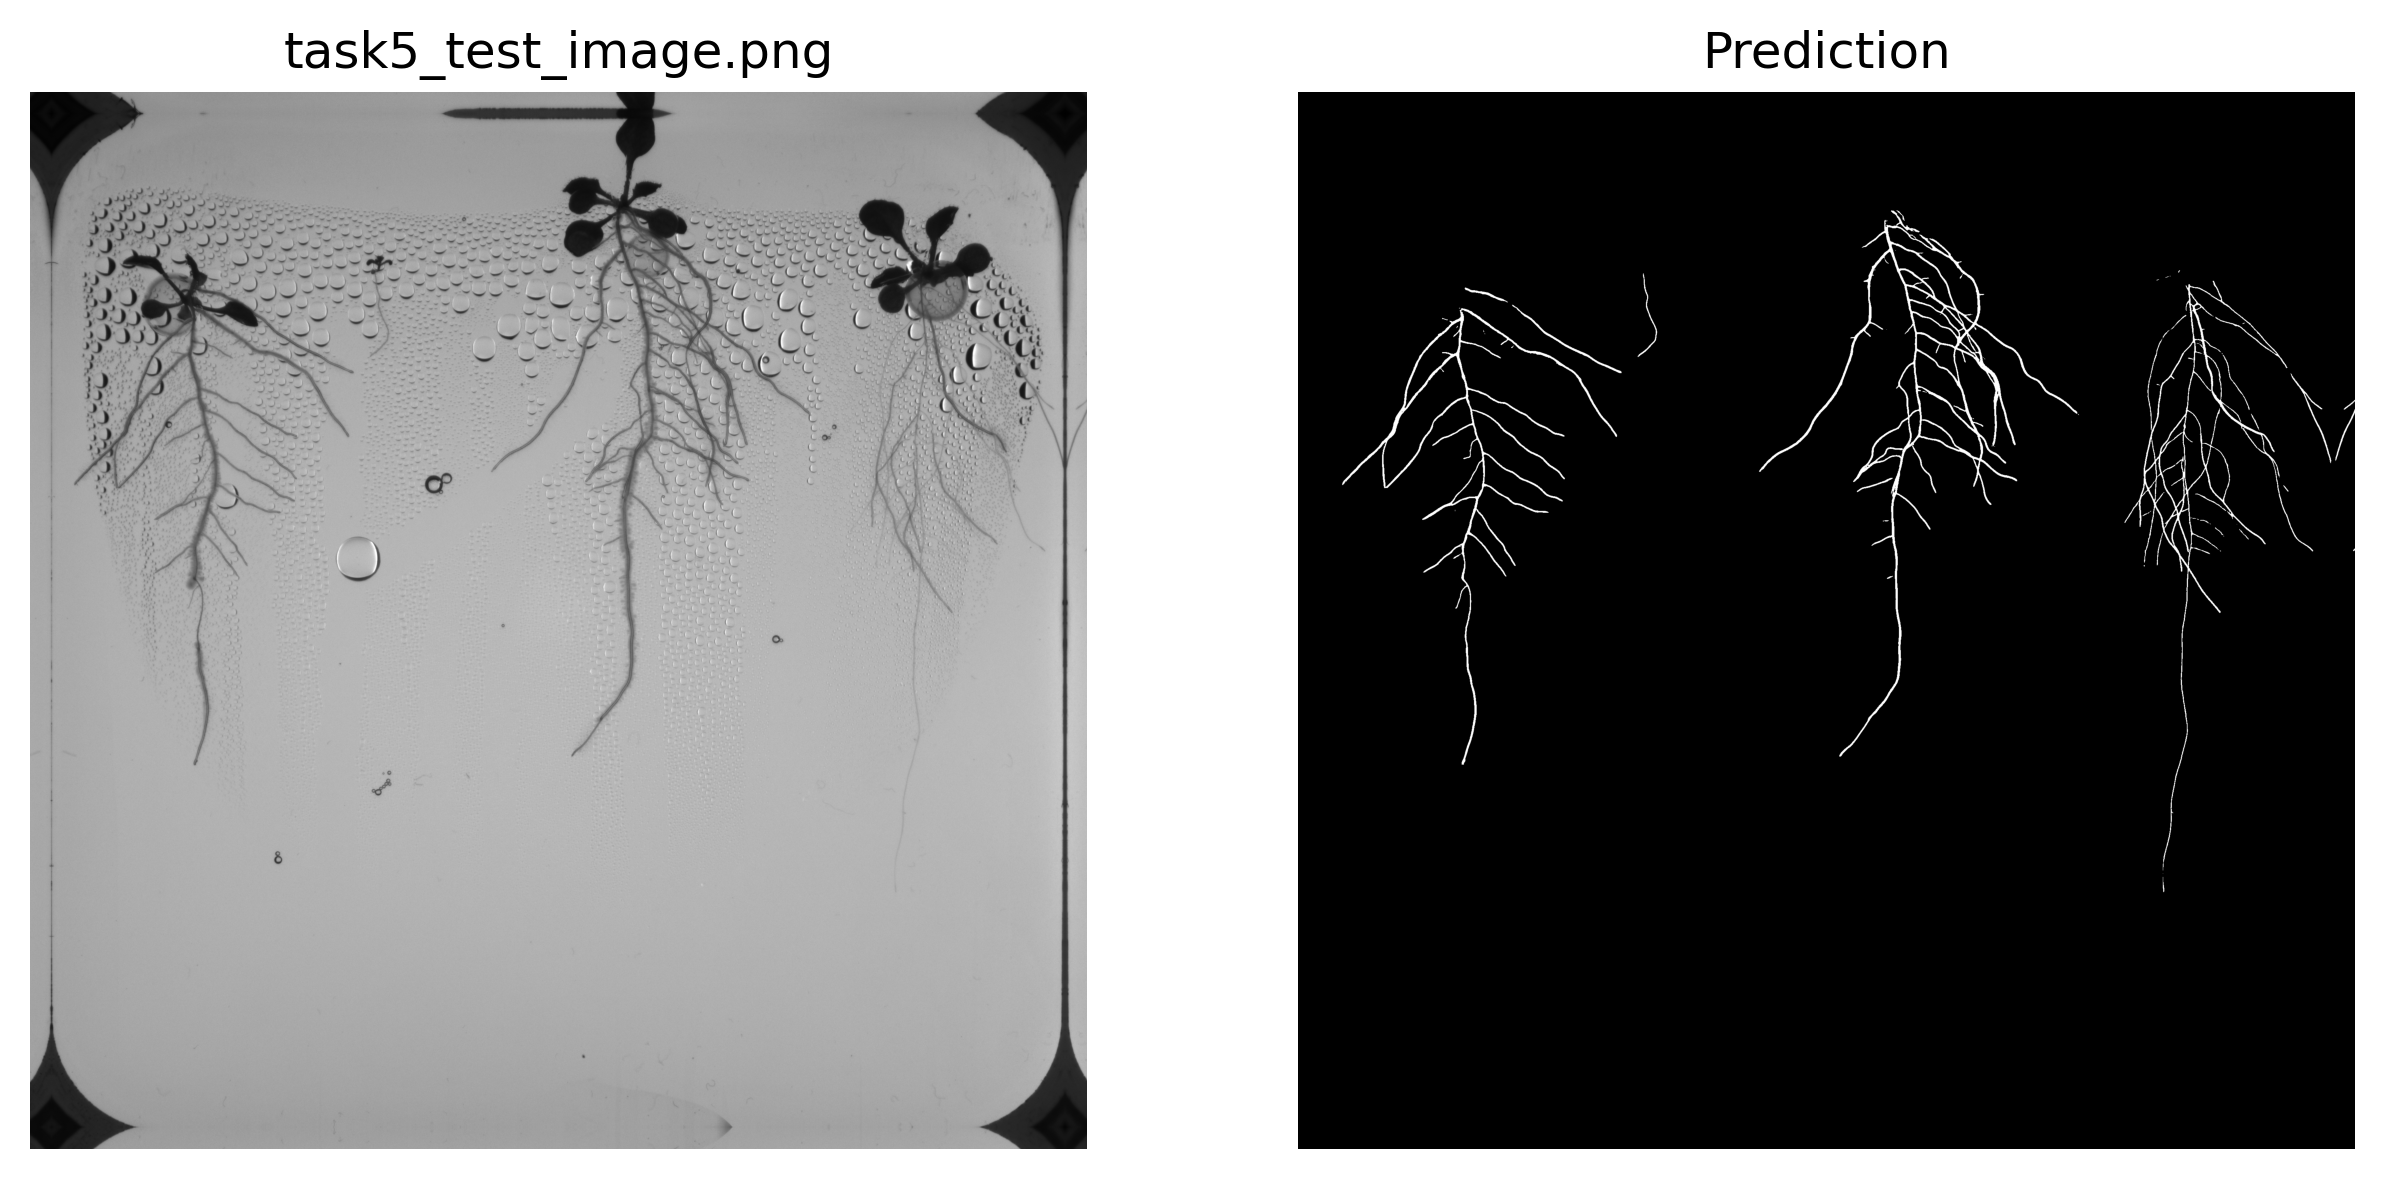

In [8]:
# PATCH
# Expand dimensions for grayscale: (H, W) -> (H, W, 1)
img_input = np.expand_dims(petri_dish_padded, axis=-1)

# Create overlapping patches
step = int(patch_size * 0.5)  # 50% overlap
patches = patchify(img_input, (patch_size, patch_size, 1), step=step)
n_h, n_w = patches.shape[0], patches.shape[1]

# Flatten patch grid into batch
patch_list = []
for i in range(n_h):
    for j in range(n_w):
        patch = patches[i, j, 0, :, :, :]  # Extract (256, 256, 1)
        patch_list.append(patch)

patches_batch = np.array(patch_list)
patches_batch = patches_batch / 255.0  # Normalize to [0, 1] as in training

# PREDICT
predictions = model.predict(patches_batch, batch_size=32, verbose=1)

# UNPATCH
# Approach: Reconstruct using averaging for overlapping regions
# This reduces boundary artifacts compared to simple stitching
padded_h, padded_w = petri_dish_padded.shape
reconstructed = np.zeros((padded_h, padded_w), dtype=np.float32)
counts = np.zeros((padded_h, padded_w), dtype=np.float32)

idx = 0
for i in range(n_h):
    for j in range(n_w):
        y_start = i * step
        x_start = j * step
        y_end = y_start + patch_size
        x_end = x_start + patch_size
        
        pred_patch = predictions[idx, :, :, 0]
        reconstructed[y_start:y_end, x_start:x_end] += pred_patch
        counts[y_start:y_end, x_start:x_end] += 1
        
        idx += 1

# Average overlapping predictions
counts = np.maximum(counts, 1)
reconstructed = reconstructed / counts

# Convert to binary mask
predicted_mask = (reconstructed > 0.5).astype(np.float32)

f, ax = plt.subplots(1, 2, dpi=300, figsize=(10, 5))
ax[0].imshow(petri_dish_padded, cmap='gray')
ax[0].axis('off')
ax[0].set_title('task5_test_image.png')
ax[1].imshow(predicted_mask, cmap='gray')
ax[1].axis('off')
ax[1].set_title('Prediction')

In [9]:
predicted_mask.shape, image.shape

((2816, 2816), (3006, 4112))

As you can see `predicted_mask` and `image` have different shapes. This is because of cropping and padding.

**REQUIREMENT:** The input and output should have the same size and should be aligned perfectly. To achieve this, you need to reverse the effects of cropping and padding added during processing. This will ensure the final mask aligns with the original image.

In [10]:
# Apply the corrections
# Step 1: Remove padding to get back to cropped size
h_crop, w_crop = petri_dish.shape
predicted_mask_unpadded = predicted_mask[top:top+h_crop, left:left+w_crop]

# Step 2: Place cropped prediction back into original image coordinates
predicted_mask_corrected = np.zeros_like(image, dtype=np.float32)
predicted_mask_corrected[y1:y2, x1:x2] = predicted_mask_unpadded

predicted_mask_corrected.shape

(3006, 4112)

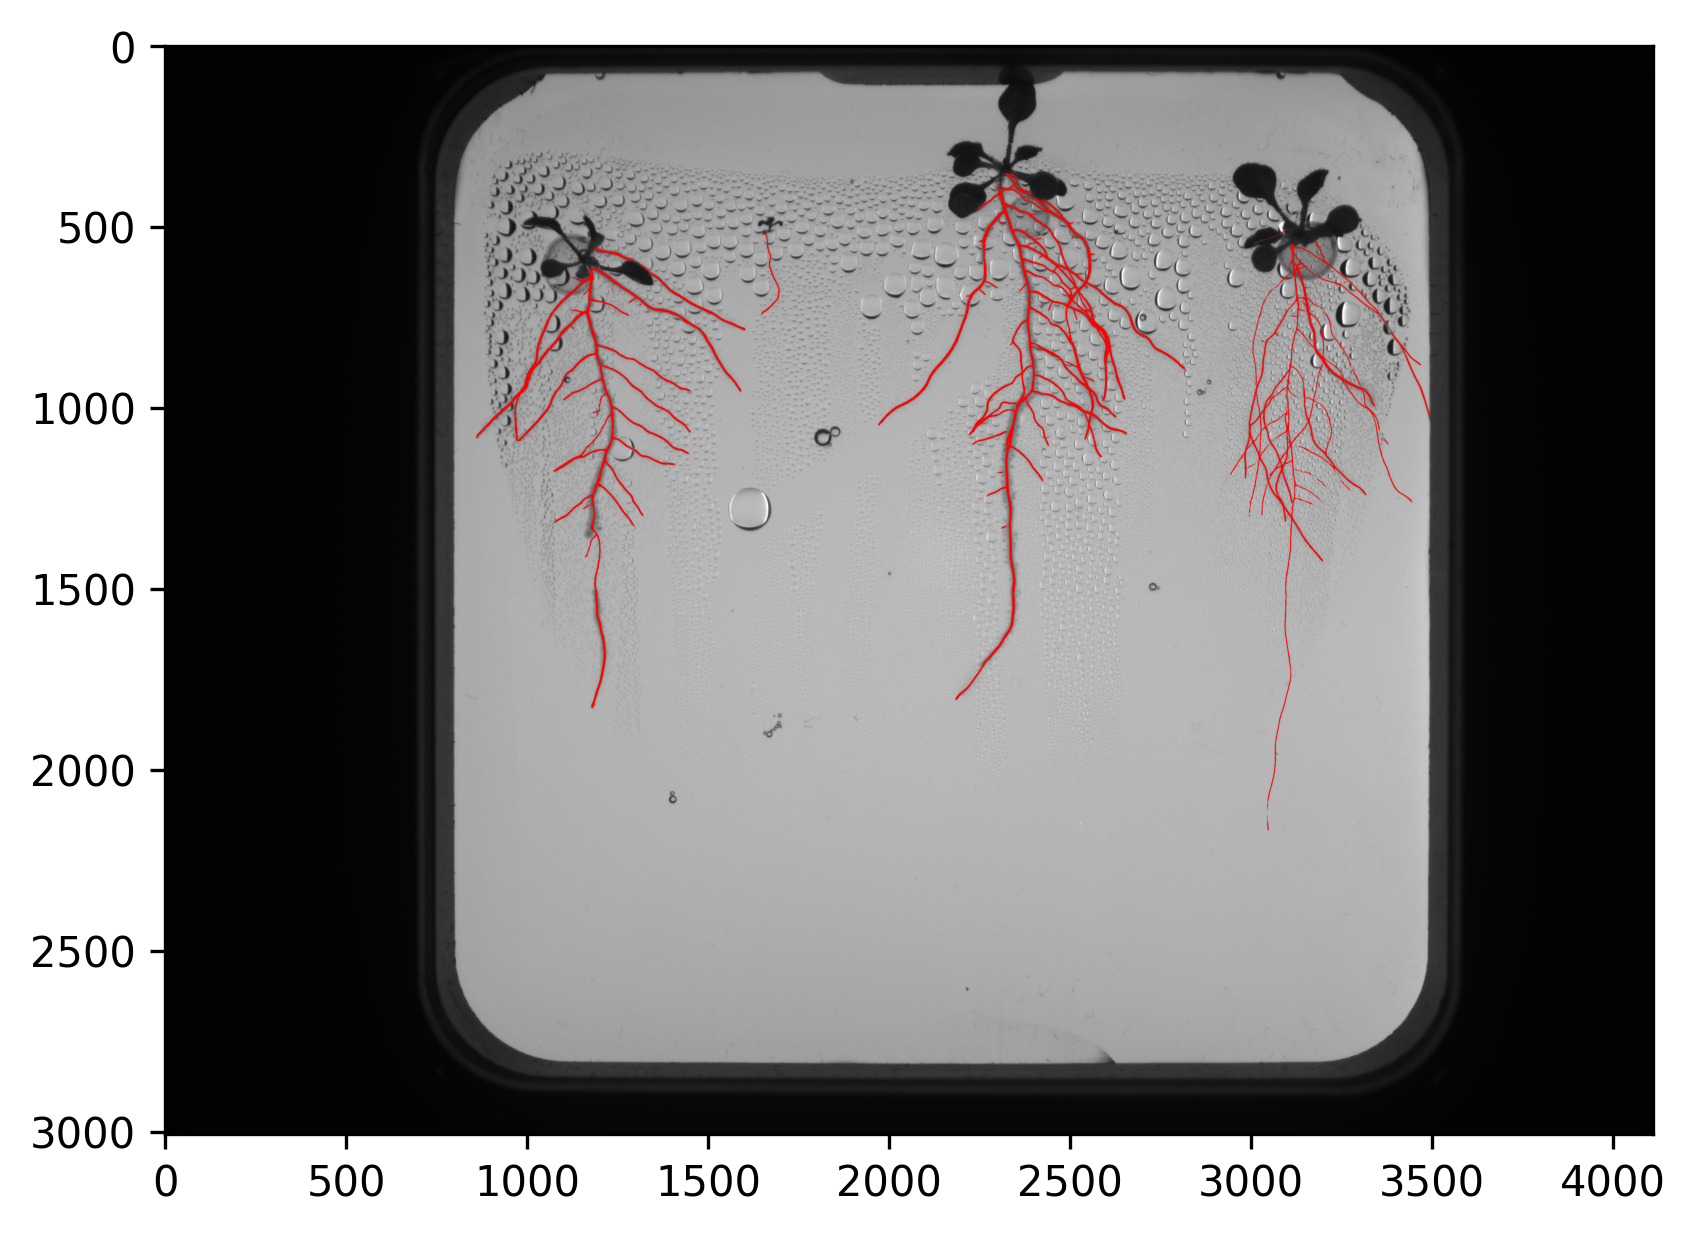

In [11]:
# REQUIREMENT: Predicted roots must align with the original image.
# REQUIREMENT: Plot such an image to prove alignment.

# Create RGB overlay: grayscale base with red mask overlay
overlay_image = np.stack([image, image, image], axis=-1).astype(np.uint8)
mask_binary = (predicted_mask_corrected > 0.5).astype(np.uint8)

# Paint predictions in red
overlay_image[:, :, 0] = np.where(mask_binary == 1, 255, overlay_image[:, :, 0])
overlay_image[:, :, 1] = np.where(mask_binary == 1, 0, overlay_image[:, :, 1])
overlay_image[:, :, 2] = np.where(mask_binary == 1, 0, overlay_image[:, :, 2])

plt.figure(dpi=300)
plt.imshow(overlay_image)

In [12]:
# REQUIREMENT: Save the predicted mask, it is a deliverable.
# REQUIREMENT: Input/Output size must be the same.
# REQUIREMENT: Predicted roots must align with the original image.
# REQUIREMENT: The predicted mask must be binary.
# REQUIREMENT: Non-root pixels must be 0, root pixels must be 255 (unlike Task 1)
# REQUIREMENT: naming convention task5_test_image_prediction_studentname_studentnumber.png
mask_image = (predicted_mask_corrected * 255).astype(np.uint8)
assert(predicted_mask_corrected.shape == image.shape)
cv2.imwrite('task5_test_image_prediction_alex_240247.png', mask_image)

True

Note: I have trained the model on the Y2B_23 dataset, since there are no labels for Y2B_24 dataset yet. The test image is from Y2B_24, this is why the predicted mask is suboptimal. Therefore do not take the performance of this prediction as a reference. Your predictions should be much better than this.